# 1. Distancias y Análisis de Componentes Principales (PCA)

Este notebook presenta el concepto de distancia en análisis multivariado y su aplicación práctica con varias métricas.
También desarrolla los fundamentos del PCA y su implementación para reducir dimensionalidad e interpretar datos.


## Objetivos
- Comprender qué es una métrica de distancia y cuándo usarla.
- Aplicar distancias Euclidiana, Manhattan, Mahalanobis y otras métricas.
- Construir e interpretar matrices de distancia.
- Ejecutar PCA e interpretar varianza explicada y componentes.

Trabaja los ejemplos con la Base de datos: [Mall Customer Segmentation Data](Mall_Customers.csv)

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import euclidean, cityblock, mahalanobis, pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

## 1. Concepto de distancia

Una distancia mide cuán diferentes son dos observaciones en un espacio de variables.
En análisis multivariado, elegir la métrica correcta cambia la interpretación de similitud.

Si dos vectores son $\mathbf{x} = (x_1, ..., x_p)$ y $\mathbf{y} = (y_1, ..., y_p)$, entonces:

- Distancia Euclidiana: $d_E(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2}$
- Distancia Manhattan: $d_M(\mathbf{x}, \mathbf{y}) = \sum_{j=1}^{p}|x_j - y_j|$
- Distancia Minkowski ($q$): $d_q(\mathbf{x}, \mathbf{y}) = \left(\sum_{j=1}^{p}|x_j-y_j|^q\right)^{1/q}$
- Distancia Mahalanobis: $d_{Mah}(\mathbf{x}, \mathbf{y}) = \sqrt{(\mathbf{x}-\mathbf{y})^T S^{-1}(\mathbf{x}-\mathbf{y})}$

La distancia de Mahalanobis usa la covarianza $S$ para ajustar por escala y correlación entre variables.

In [78]:
# Dataset sintético con 3 variables correlacionadas
n = 120
x1 = np.random.normal(50, 10, n)
x2 = 0.7 * x1 + np.random.normal(0, 5, n)
x3 = -0.4 * x1 + 0.5 * x2 + np.random.normal(0, 6, n)
grupo = np.where(x1 > np.median(x1), 'A', 'B')

df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3, 'grupo': grupo})
df.head()

,x1,x2,x3,grupo
0,54.967142,42.432159,-5.525902,A
1,48.617357,29.485213,-5.392755,B
2,56.476885,46.547791,3.713065,A
3,65.230299,38.651954,-1.571611,A
4,47.658466,36.295212,-8.117559,B


## 2. Distancia Euclidiana y Manhattan

Tomemos dos observaciones del dataset para comparar ambas métricas.

In [79]:
a = df.loc[0, ['x1', 'x2', 'x3']].values
b = df.loc[1, ['x1', 'x2', 'x3']].values

dist_euclidiana = euclidean(a, b)
dist_manhattan = cityblock(a, b)

pd.Series({
    'Euclidiana': dist_euclidiana,
    'Manhattan': dist_manhattan
})

Euclidiana    14.420850
Manhattan     19.429877
dtype: float64

## 3. Distancia Mahalanobis

A diferencia de Euclidiana/Manhattan, Mahalanobis considera la estructura de covarianza de los datos.

In [80]:
X = df[['x1', 'x2', 'x3']].values
S = np.cov(X, rowvar=False)
S_inv = np.linalg.inv(S)

dist_mahalanobis = mahalanobis(a, b, S_inv)
dist_mahalanobis

np.float64(1.9788473601222558)

## 4. Otras métricas: Minkowski y Coseno

- Minkowski generaliza Euclidiana (q=2) y Manhattan (q=1).
- Coseno mide diferencia angular, útil en datos de texto o embeddings.

In [81]:
dist_minkowski_q3 = pdist(X[:2], metric='minkowski', p=3)[0]
dist_coseno = pdist(X[:2], metric='cosine')[0]

# Ejemplo Hamming con variables binarias
binarios = np.array([[1, 0, 1, 1], [1, 1, 0, 1]])
dist_hamming = pdist(binarios, metric='hamming')[0]

pd.Series({
    'Minkowski q=3': dist_minkowski_q3,
    'Coseno': dist_coseno,
    'Hamming (binario)': dist_hamming
})

Minkowski q=3        13.437268
Coseno                0.006359
Hamming (binario)     0.500000
dtype: float64

## 5. Matriz de distancias

Construimos una matriz de distancias Euclidianas para un subconjunto de observaciones.

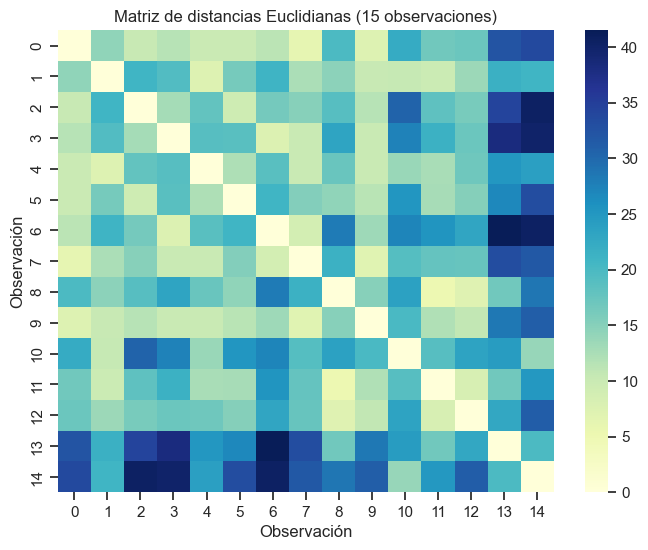

In [82]:
subset = df[['x1', 'x2', 'x3']].head(15).values
matriz_dist = squareform(pdist(subset, metric='euclidean'))

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_dist, cmap='YlGnBu')
plt.title('Matriz de distancias Euclidianas (15 observaciones)')
plt.xlabel('Observación')
plt.ylabel('Observación')
plt.show()

## 6. Fundamentos del Análisis de Componentes Principales- PCA

El PCA busca nuevas variables (componentes principales) que:
1. Sean combinaciones lineales de las variables originales.
2. Capten la mayor varianza posible en orden descendente.
3. Sean ortogonales entre sí.

**Idea clave:** si pocas componentes explican gran parte de la varianza, podemos reducir dimensionalidad con mínima pérdida de información.

Antes de PCA se recomienda estandarizar variables para evitar que una escala domine el análisis.

### 6.1. Definicón del Análisis de Componentes Principales 

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que nos permite simplificar conjuntos de datos complejos (con muchas variables) manteniendo la mayor cantidad de información posible.

Imagina que como administrador tienes 50 indicadores de desempeño (KPIs) de una empresa, el PCA es como un "resumen inteligente", la herramienta permite condensar en 2 o 3 "super-indicadores" (Componentes) que explican la salud del negocio porque se encuentran correlacionados.

El PCA elimina esa redundancia creando nuevas variables llamadas Componentes Principales (CP).

CP1: Captura la mayor variabilidad posible del negocio por ejemplo:  "Tamaño de la Operación".

CP2: Captura la siguiente mayor variabilidad que no fue explicada por el primero por ejemplo "Eficiencia de Margen".

#### 6.1.1. Explicación de varianza 

La varianza nos dice qué tan dispersos están nuestros datos con respecto al promedio.

Imagina que eres el gerente de una cadena de pizzerías y analizas el tiempo de entrega de dos locales:

Local A: Siempre entrega en 30 minutos (Promedio = 30).

Local B: A veces entrega en 10 minutos y a veces en 50 minutos (Promedio = 30).

Ambos tienen el mismo promedio, pero el Local B tiene una varianza mucho más alta. Para un administrador, el Local B es un problema: no puedes prometerle nada al cliente porque el proceso es inestable.


Matemáticamente, la varianza $\sigma^2$ para poblaciones o ($s^2$ para muestras) es el promedio de los cuadrados de las desviaciones de cada dato respecto a su media.$$s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$$

Como la varianza está expresada en unidades al cuadrado (ej. "dólares al cuadrado"), es difícil de interpretar para un informe de gerencia. Por eso usamos la Desviación Estándar ($\sigma$):

* Varianza: Nos sirve para cálculos estadísticos profundos y modelos de regresión.
* Desviación Estándar: Es la raíz cuadrada de la varianza. Nos devuelve a las unidades originales (ej. "dólares").



### 6.2. Pasos para hacer un correcto PCA

Para este ejemplo se usará la base de datos de los KPI's de una empresa. [Descargue la BD aquí](base_kpis_sucia.csv)

#### Paso 1: Selección y Preparación de Variables

El PCA funciona mejor cuando las variables están correlacionadas. Si las variables no tienen nada que ver entre sí, el PCA no podrá resumirlas.

Variables Numéricas: Asegúrate de que todas las variables sean cuantitativas.

Limpieza: Elimina o imputa valores nulos, ya que el PCA es sensible a ellos.

Detección de Outliers: Valores extremos pueden "torcer" la dirección de los componentes, dándote una visión sesgada.


In [83]:
df_kpis = pd.read_csv("base_kpis_sucia.csv")
df_kpis.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   OP_Ciclo_Produccion         500 non-null    float64
 1   OP_Tasa_Defectos            500 non-null    float64
 2   OP_Disponibilidad_Maq       500 non-null    float64
 3   OP_Costo_Unitario           497 non-null    float64
 4   OP_Merma_Materia_Prima      497 non-null    float64
 5   OP_Cumplimiento_Plan        500 non-null    float64
 6   OP_Eficiencia_Energetica    500 non-null    float64
 7   OP_Rotacion_Inventario      500 non-null    float64
 8   OP_Tiempo_Set_Up            500 non-null    float64
 9   OP_Productividad_HH         499 non-null    float64
 10  OP_Lead_Time_Prov           500 non-null    float64
 11  OP_Capacidad_Utilizada      500 non-null    float64
 12  FIN_Margen_EBITDA           500 non-null    float64
 13  FIN_ROI                     500 non-null    fl

In [84]:
# Resumen general de las variables del DataFrame
resumen_variables = df_kpis.describe().T.copy()
resumen_variables["tipo"] = df_kpis.dtypes.values
resumen_variables["nulos"] = df_kpis.isna().sum().values

# Reordenar columnas para facilitar lectura
resumen_variables = resumen_variables[
    ["tipo", "nulos", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(resumen_variables)

,tipo,nulos,count,mean,std,min,25%,50%,75%,max
OP_Ciclo_Produccion,float64,0,500.0,100.261701,15.154611,62.065924,90.297978,99.781628,109.741759,166.273254
OP_Tasa_Defectos,float64,0,500.0,100.644993,15.282825,54.074770,90.404804,100.231065,110.789586,166.538856
OP_Disponibilidad_Maq,float64,0,500.0,100.268510,15.815906,50.769239,90.162869,99.604762,111.247574,152.918326
OP_Costo_Unitario,float64,3,497.0,100.130990,15.311606,57.559901,89.674157,99.978779,110.748173,157.787429
OP_Merma_Materia_Prima,float64,3,497.0,100.160283,15.734809,55.857767,89.500112,99.509063,110.596431,165.608039
OP_Cumplimiento_Plan,float64,0,500.0,100.009938,15.725900,46.857918,89.248208,99.259452,110.129978,160.047099
OP_Eficiencia_Energetica,float64,0,500.0,100.008009,15.586936,47.315918,89.795801,99.872805,109.944298,157.988208
OP_Rotacion_Inventario,float64,0,500.0,99.632401,15.277447,55.178564,89.514641,99.750395,110.025771,152.160703
OP_Tiempo_Set_Up,float64,0,500.0,100.080003,15.603573,54.740713,89.992641,100.551869,109.998008,157.597258
OP_Productividad_HH,float64,1,499.0,99.926571,15.446723,52.743097,89.869578,99.469218,110.557312,158.102629


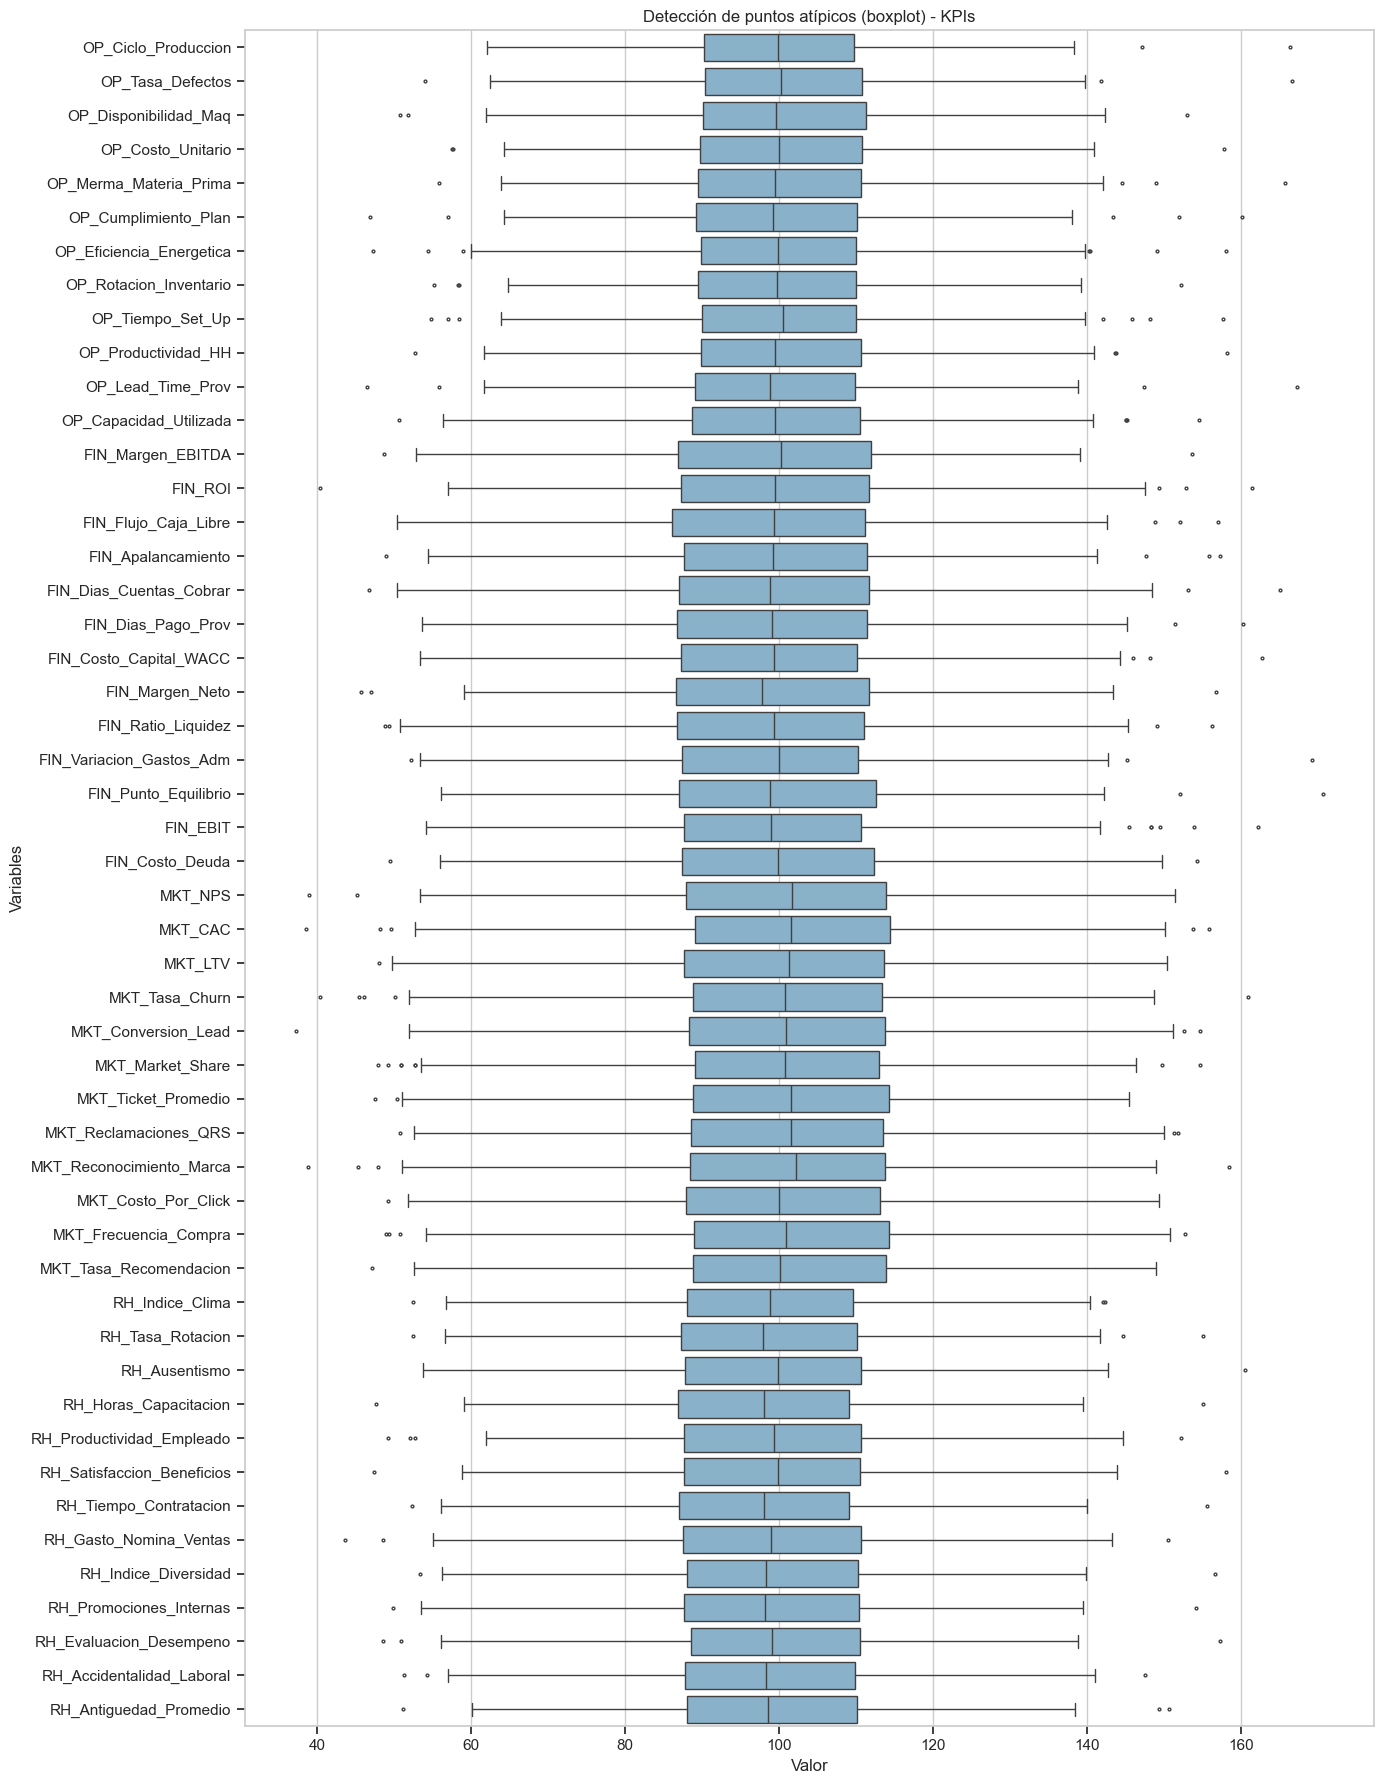

Top 10 variables con más puntos atípicos:


,n_outliers
MKT_Market_Share,8
OP_Eficiencia_Energetica,7
OP_Tiempo_Set_Up,7
FIN_EBIT,6
MKT_CAC,5
MKT_Tasa_Churn,5
OP_Cumplimiento_Plan,5
OP_Capacidad_Utilizada,5
FIN_ROI,4
FIN_Ratio_Liquidez,4


In [85]:
# Seleccionar solo variables numéricas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = df_kpis.select_dtypes(include=np.number).columns
# Boxplot general para detectar puntos atípicos por variable
plt.figure(figsize=(14, 18))
sns.boxplot(data=df_kpis[columnas_numericas], orient="h", color="#7FB3D5", fliersize=2)
plt.title("Detección de puntos atípicos (boxplot) - KPIs")
plt.xlabel("Valor")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# Resumen de cantidad de atípicos por variable usando regla IQR
Q1 = df_kpis[columnas_numericas].quantile(0.25)
Q3 = df_kpis[columnas_numericas].quantile(0.75)
IQR = Q3 - Q1

outliers_por_variable = (
    ((df_kpis[columnas_numericas] < (Q1 - 1.5 * IQR)) |
     (df_kpis[columnas_numericas] > (Q3 + 1.5 * IQR)))
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 variables con más puntos atípicos:")
display(outliers_por_variable.head(10).to_frame(name="n_outliers"))



In [86]:
# 1) Eliminar filas con datos faltantes en variables numéricas
#df_kpis.info()
df_kpis_sin_nulos = df_kpis.dropna()


# 2) Eliminar outliers con regla IQR (1.5 * IQR) en variables numéricas
Q1_limpio = df_kpis_sin_nulos[columnas_numericas].quantile(0.25)
Q3_limpio = df_kpis_sin_nulos[columnas_numericas].quantile(0.75)
IQR_limpio = Q3_limpio - Q1_limpio

lim_inf = Q1_limpio - 1.5 * IQR_limpio
lim_sup = Q3_limpio + 1.5 * IQR_limpio

mascara_sin_outliers = ~(
    (df_kpis_sin_nulos[columnas_numericas] < lim_inf) |
    (df_kpis_sin_nulos[columnas_numericas] > lim_sup)
).any(axis=1)

df_kpis_limpio = df_kpis_sin_nulos.loc[mascara_sin_outliers].reset_index(drop=True)

print(f"Forma original: {df_kpis.shape}")
print(f"Sin nulos: {df_kpis_sin_nulos.shape}")
print(f"Sin nulos y sin outliers: {df_kpis_limpio.shape}")

# Si quieres reemplazar la base original:
df_kpis = df_kpis_limpio.copy()
df_kpis.info()

Forma original: (500, 50)
Sin nulos: (472, 50)
Sin nulos y sin outliers: (419, 50)
<class 'pandas.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   OP_Ciclo_Produccion         419 non-null    float64
 1   OP_Tasa_Defectos            419 non-null    float64
 2   OP_Disponibilidad_Maq       419 non-null    float64
 3   OP_Costo_Unitario           419 non-null    float64
 4   OP_Merma_Materia_Prima      419 non-null    float64
 5   OP_Cumplimiento_Plan        419 non-null    float64
 6   OP_Eficiencia_Energetica    419 non-null    float64
 7   OP_Rotacion_Inventario      419 non-null    float64
 8   OP_Tiempo_Set_Up            419 non-null    float64
 9   OP_Productividad_HH         419 non-null    float64
 10  OP_Lead_Time_Prov           419 non-null    float64
 11  OP_Capacidad_Utilizada      419 non-null    float64
 12  FIN_Margen_EBITDA   

#### Paso 2: Estandarización de los Datos 

Este es el paso donde fallan la mayoría de los análisis. El PCA busca maximizar la varianza. Si tienes una variable "Ingresos" (en miles) y otra "Tasa de interés" (en decimales), el PCA creerá que el Ingreso es más importante solo porque sus números son más grandes.

**Estandarizadores:**

* **Z-Score Standardization (la mas adecuada al contexto)**

Debes centrar la media en 0 y la desviación estándar en 1 para todas las variables.

Fórmula: $$z = \frac{x - \mu}{\sigma}$$

![normal_desvest](./imagenes/normal_desvest.png)

* **Min-Max Scaling (Normalización)**
En lugar de usar la desviación estándar, este método escala los datos en un rango fijo, generalmente de 0 a 1.

Cómo funciona: Resta el valor mínimo y divide por el rango (Máximo - Mínimo).

Cuándo usarlo: Útil si tienes KPIs que tienen límites estrictos (por ejemplo, una calificación de servicio de 1 a 5 o porcentajes de 0 a 100) y quieres preservar las distancias exactas dentro de ese rango.

Riesgo: Es muy sensible a los outliers (valores atípicos). Si una tienda tuvo una venta accidentalmente gigante, comprimirá al resto de las tiendas en un rango muy pequeño (ej. de 0 a 0.01).

* **Robust Scaling (Para datos "sucios" o con Outliers)**

En el mundo real de los negocios, los datos suelen tener errores o eventos extraordinarios (una huelga que detuvo la producción, una venta masiva única).

Cómo funciona: Utiliza la mediana y el rango intercuartílico (IQR) en lugar de la media y la desviación estándar.

Ventaja: La media y la desviación estándar se ven muy afectadas por valores extremos; la mediana no.

Cuándo usarlo: Si en tu lista de 50 KPIs financieros tienes empresas o meses con valores extremadamente locos que no quieres que arruinen la estructura de tus componentes principales.

In [87]:
from sklearn.preprocessing import StandardScaler

# Estandarización de las variables (media = 0, desviación estándar = 1)
scaler_kpis = StandardScaler()

df_kpis_estandarizado = pd.DataFrame(
    scaler_kpis.fit_transform(df_kpis_sin_nulos),
    columns=df_kpis_sin_nulos.columns,
    index=df_kpis_sin_nulos.index
)

display(df_kpis_estandarizado.head())

# Verificación rápida
display(df_kpis_estandarizado.describe().loc[['mean', 'std']].round(2))


,OP_Ciclo_Produccion,OP_Tasa_Defectos,OP_Disponibilidad_Maq,OP_Costo_Unitario,OP_Merma_Materia_Prima,OP_Cumplimiento_Plan,OP_Eficiencia_Energetica,OP_Rotacion_Inventario,OP_Tiempo_Set_Up,OP_Productividad_HH,...,RH_Horas_Capacitacion,RH_Productividad_Empleado,RH_Satisfaccion_Beneficios,RH_Tiempo_Contratacion,RH_Gasto_Nomina_Ventas,RH_Indice_Diversidad,RH_Promociones_Internas,RH_Evaluacion_Desempeno,RH_Accidentalidad_Laboral,RH_Antiguedad_Promedio
0,0.798225,0.910056,0.707028,0.262288,0.654725,-0.132698,0.868778,0.237566,0.177651,0.353934,...,-0.049703,0.470749,1.185133,0.414667,0.146340,0.428992,0.459330,0.419575,0.311488,-0.370032
1,0.488942,0.127965,-0.322451,-0.186712,0.170137,-0.407372,-0.336771,-0.118196,-0.568935,-0.281988,...,0.344327,0.706297,0.444193,-0.035705,0.072897,0.409404,0.343438,0.943395,-0.125293,0.298852
2,0.170120,0.618602,0.343029,0.371961,0.510381,0.490997,0.647176,0.680154,0.121824,0.051861,...,-0.308083,-0.550806,-0.887424,-0.798340,-0.253528,-0.554489,-0.917567,-0.571199,-0.846302,-1.592142
3,1.709514,1.249445,1.438190,1.388209,1.264285,2.069292,1.501767,1.701900,1.623207,1.396808,...,0.689549,0.791832,0.948809,0.489906,1.262878,0.341605,0.605482,0.916795,0.626334,0.636121
4,-0.466636,-0.040990,-0.292744,-0.852158,-0.582451,-0.045649,-0.389416,-0.656599,-0.292611,0.013384,...,-0.897628,-1.205851,-1.000609,-0.860321,-1.593861,-0.339533,-1.084320,-1.230415,-1.116795,-0.988663


,OP_Ciclo_Produccion,OP_Tasa_Defectos,OP_Disponibilidad_Maq,OP_Costo_Unitario,OP_Merma_Materia_Prima,OP_Cumplimiento_Plan,OP_Eficiencia_Energetica,OP_Rotacion_Inventario,OP_Tiempo_Set_Up,OP_Productividad_HH,...,RH_Horas_Capacitacion,RH_Productividad_Empleado,RH_Satisfaccion_Beneficios,RH_Tiempo_Contratacion,RH_Gasto_Nomina_Ventas,RH_Indice_Diversidad,RH_Promociones_Internas,RH_Evaluacion_Desempeno,RH_Accidentalidad_Laboral,RH_Antiguedad_Promedio
mean,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,...,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


#### Paso 3: Cálculo de la Matriz de Covarianza (o Correlación)

El algoritmo analiza cómo se mueven las variables en conjunto.

Si cuando sube el "Gasto en Publicidad" también sube el "Volumen de Ventas", el PCA identifica que estas dos pueden fusionarse en un solo componente (ej. "Impulso Comercial").

1. **La Matriz de Covarianza:**
La covarianza mide la dirección de la relación lineal entre dos variables.

¿Qué nos dice?:

Positiva: Las dos variables suben o bajan juntas (ej. Ventas e Inventario).

Negativa: Cuando una sube, la otra baja (ej. Precio y Demanda).

Cero: No hay una relación lineal clara.

El Problema: La covarianza depende de las unidades de medida. Si mides los ingresos en Pesos Colombianos, la covarianza será un número gigante; si los mides en Dólares, será un número pequeño. Esto hace que sea imposible comparar la "fuerza" de la relación entre diferentes pares de variables.

![licensed-image.jpeg](./imagenes/licensed-image.jpeg)

2. **La Matriz de Correlación:**

La correlación es simplemente la covarianza estandarizada. Para obtenerla, dividimos la covarianza por el producto de las desviaciones estándar de las variables.

El Rango: Siempre va de -1 a +1.

+1: Relación positiva perfecta.

-1: Relación negativa perfecta.

0: Ausencia total de relación lineal.

**La Ventaja:** Es "adimensional". Puedes comparar la relación entre "Satisfacción del Cliente (1-5)" y "Ventas (Millones)" de forma directa.
**Diferencias Clave para la Toma de Decisiones:**

| Característica   | Matriz de Covarianza                                 | Matriz de Correlación                                 |
|------------------|------------------------------------------------------|-------------------------------------------------------|
| Unidades         | Mantiene las unidades originales (²).                | No tiene unidades (es un índice).                     |
| Rango            | De −∞ a +∞.                                          | De −1 a +1.                                           |
| Uso Principal    | Cálculos internos del PCA (identifica varianza).     | Entender la fuerza de la relación de un vistazo.      |
| Interpretación   | Difícil (¿es 500 mucho o poco?).                     | Fácil (0.85 es una relación muy fuerte).              |


3. **¿Por qué son vitales para el PCA?**
El PCA utiliza estas matrices como punto de partida:

Identificar Redundancia: Si la matriz de correlación muestra un 0.95 entre "Gasto en Marketing Digital" y "Gasto en Redes Sociales", el PCA sabe que puede combinar esas dos variables en un solo componente sin perder casi nada de información.

Eliminar Ruido: Las variables que tienen correlaciones cercanas a 0 con todas las demás suelen ser "ruido" o variables independientes que el PCA tratará de aislar.

Dimensión de la matriz de covarianzas: (50, 50)


,OP_Ciclo_Produccion,OP_Tasa_Defectos,OP_Disponibilidad_Maq,OP_Costo_Unitario,OP_Merma_Materia_Prima,OP_Cumplimiento_Plan,OP_Eficiencia_Energetica,OP_Rotacion_Inventario,OP_Tiempo_Set_Up,OP_Productividad_HH,...,RH_Horas_Capacitacion,RH_Productividad_Empleado,RH_Satisfaccion_Beneficios,RH_Tiempo_Contratacion,RH_Gasto_Nomina_Ventas,RH_Indice_Diversidad,RH_Promociones_Internas,RH_Evaluacion_Desempeno,RH_Accidentalidad_Laboral,RH_Antiguedad_Promedio
OP_Ciclo_Produccion,1.002,0.901,0.899,0.902,0.901,0.895,0.890,0.895,0.897,0.901,...,0.020,0.027,0.024,0.043,0.042,0.037,0.019,0.043,0.030,0.062
OP_Tasa_Defectos,0.901,1.002,0.897,0.891,0.897,0.883,0.882,0.885,0.897,0.902,...,0.003,0.022,0.013,0.038,0.031,0.032,0.016,0.018,0.028,0.047
OP_Disponibilidad_Maq,0.899,0.897,1.002,0.895,0.902,0.895,0.896,0.904,0.905,0.906,...,0.023,0.031,0.036,0.060,0.049,0.039,0.022,0.038,0.045,0.073
OP_Costo_Unitario,0.902,0.891,0.895,1.002,0.897,0.901,0.906,0.905,0.900,0.906,...,0.030,0.045,0.041,0.048,0.055,0.037,0.016,0.038,0.044,0.075
OP_Merma_Materia_Prima,0.901,0.897,0.902,0.897,1.002,0.888,0.895,0.888,0.900,0.894,...,0.034,0.044,0.025,0.055,0.041,0.035,0.023,0.042,0.051,0.076
OP_Cumplimiento_Plan,0.895,0.883,0.895,0.901,0.888,1.002,0.888,0.894,0.895,0.889,...,0.001,0.007,0.007,0.030,0.030,0.018,0.011,0.014,0.013,0.043
OP_Eficiencia_Energetica,0.890,0.882,0.896,0.906,0.895,0.888,1.002,0.904,0.899,0.895,...,0.020,0.041,0.047,0.048,0.055,0.031,0.011,0.036,0.036,0.069
OP_Rotacion_Inventario,0.895,0.885,0.904,0.905,0.888,0.894,0.904,1.002,0.895,0.897,...,0.027,0.037,0.036,0.060,0.063,0.043,0.031,0.032,0.045,0.077
OP_Tiempo_Set_Up,0.897,0.897,0.905,0.900,0.900,0.895,0.899,0.895,1.002,0.898,...,0.020,0.028,0.025,0.046,0.045,0.031,0.006,0.032,0.038,0.067
OP_Productividad_HH,0.901,0.902,0.906,0.906,0.894,0.889,0.895,0.897,0.898,1.002,...,0.004,0.042,0.032,0.051,0.030,0.023,0.015,0.019,0.031,0.063


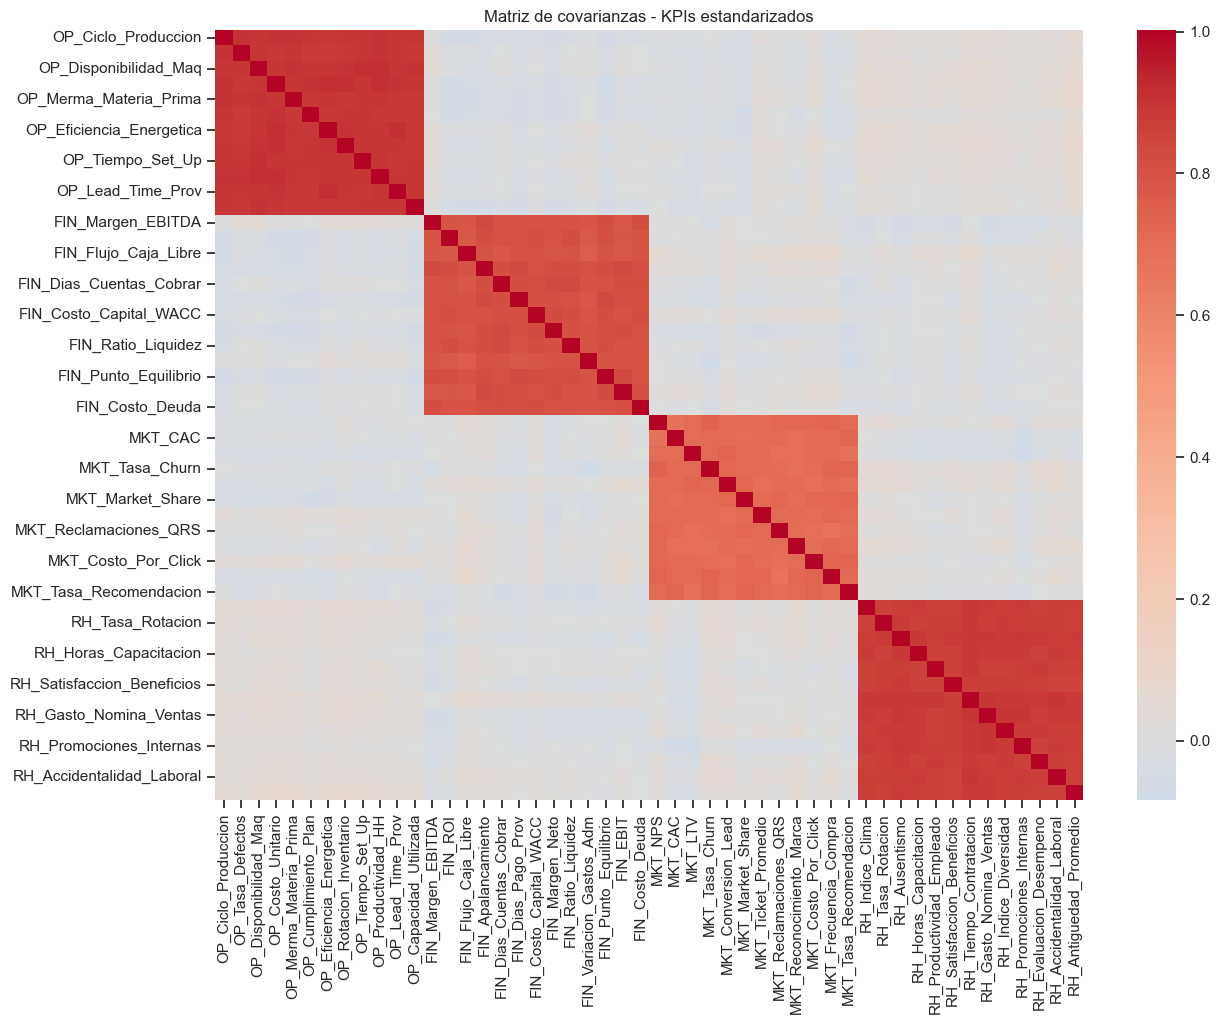

In [88]:
# Matriz de covarianzas de la base estandarizada
matriz_covarianza = df_kpis_estandarizado.cov()

print("Dimensión de la matriz de covarianzas:", matriz_covarianza.shape)
display(matriz_covarianza.round(3))

# Visualización
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_covarianza, cmap="coolwarm", center=0)
plt.title("Matriz de covarianzas - KPIs estandarizados")
plt.show()

#### Paso 4: Extracción de Autovalores y Autovectores

Aquí es donde ocurre la "magia" matemática:

Autovectores (Principal Components): Son las nuevas direcciones (ejes). El PC1 es la dirección que captura la mayor cantidad de dispersión de los datos.

Autovalores (Eigenvalues): Representan la "cantidad" de varianza que retiene cada componente. Un autovalor alto significa que ese componente es muy informativo.

En nuestro ejemplo ilustativo **si el PCA es una máquina de simplificar, los autovectores son las direcciones en las que se mueve el negocio y los autovalores son la fuerza o importancia de cada dirección.**

* 1. **El Concepto de "Eje"**

Imagina que tienes una nube de puntos que representa la relación entre Ventas y Gasto en Publicidad. Generalmente, verás una forma alargada (como un balón de fútbol americano).

* **El Autovector:** Es la flecha que atraviesa el balón por su parte más larga. Nos indica la "dirección" principal de los datos.

* **El Autovalor:** Es un número que nos dice qué tan largo es ese balón en esa dirección. Si el número es grande, esa dirección explica mucha información (varianza).

2. **¿Qué es un Autovector? (La Dirección):**

En el contexto de tus 50 KPIs, un autovector es una combinación lineal de las variables originales.

Matemáticamente, un autovector $v$ de una matriz $A$ cumple que: $$A \cdot v = \lambda \cdot v$$ 

Al multiplicar la matriz de datos por el autovector, la dirección no cambia, solo se estira o encoge.

El primer autovector ($PC_1$) será la dirección que capture la mayor variabilidad de la empresa. Si este autovector tiene pesos altos en KPIs de Finanzas, significa que la mayor diferencia entre tu unidades es de origen financiero.

3. **¿Qué es un Autovalor? (La Importancia):**

Cada autovector tiene un autovalor asociado ($\lambda$). En el PCA, el autovalor representa la cantidad de varianza capturada por ese componente.Suma de Autovalores: La suma de todos los autovalores es igual a la varianza total de los datos originales.Cálculo de Importancia: Para saber cuánto explica el Componente 1, dividimos su autovalor por la suma total:$$\% \text{Varianza Explicada} = \frac{\lambda_i}{\sum \lambda} \times 100$$Ejemplo Real: Si el autovalor del Componente 1 es 15 y la suma de todos los autovalores de los 50 KPIs es 50, entonces el primer componente explica el 30% de todo lo que sucede en la empresa.

![autovalor_autovector.jpeg](./imagenes/autovalor_autovector.jpeg)



,Componente,Autovalor,Varianza_Explicada_%,Varianza_Acumulada_%
0,PC1,11.759578,23.469328,23.469328
1,PC2,10.833103,21.620304,45.089632
2,PC3,10.451976,20.859663,65.949295
3,PC4,8.812230,17.587120,83.536416
4,PC5,0.377182,0.752765,84.289181
5,PC6,0.369973,0.738378,85.027559
6,PC7,0.351726,0.701961,85.729520
7,PC8,0.335104,0.668788,86.398308
8,PC9,0.326007,0.650632,87.048940
9,PC10,0.321398,0.641434,87.690374


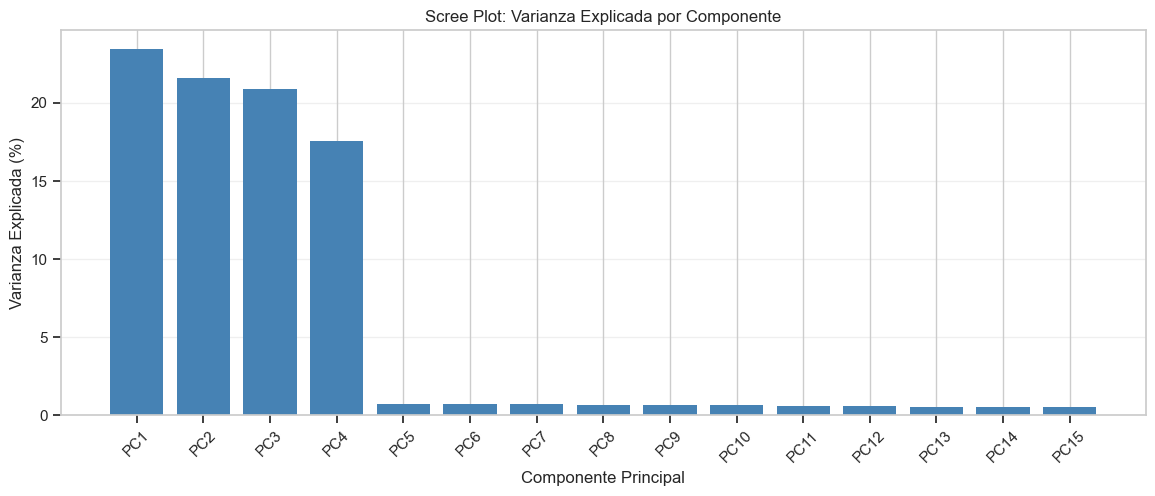

In [89]:
# Extracción de autovalores y autovectores de la matriz de covarianzas
autovalores, autovectores = np.linalg.eig(matriz_covarianza)

# Ordenar en orden descendente
orden = np.argsort(autovalores)[::-1]
autovalores_ordenados = autovalores[orden]
autovectores_ordenados = autovectores[:, orden]

# Crear DataFrame para visualizar los autovalores
df_autovalores = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(autovalores_ordenados))],
    'Autovalor': autovalores_ordenados,
    'Varianza_Explicada_%': (autovalores_ordenados / autovalores_ordenados.sum()) * 100,
    'Varianza_Acumulada_%': np.cumsum((autovalores_ordenados / autovalores_ordenados.sum()) * 100)
})

display(df_autovalores.head(15))

# Visualización: Scree Plot
fig, (ax1) = plt.subplots(1, figsize=(14, 5))

# Gráfico 1: Varianza explicada por componente
ax1.bar(df_autovalores['Componente'][:15], df_autovalores['Varianza_Explicada_%'][:15], color='steelblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada (%)')
ax1.set_title('Scree Plot: Varianza Explicada por Componente')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)



#### Paso 5: Selección del Número de Componentes

No queremos pasar de 50 variables a 50 componentes (no estaríamos resumiendo nada). Usamos dos criterios:Criterio de Kaiser: Mantener solo componentes con autovalores $> 1$.Gráfico de Sedimentación (Scree Plot): Buscamos el "punto de codo" donde la varianza explicada deja de caer drásticamente.Varianza Acumulada: Normalmente se busca retener entre el 70% y el 90% de la varianza total.

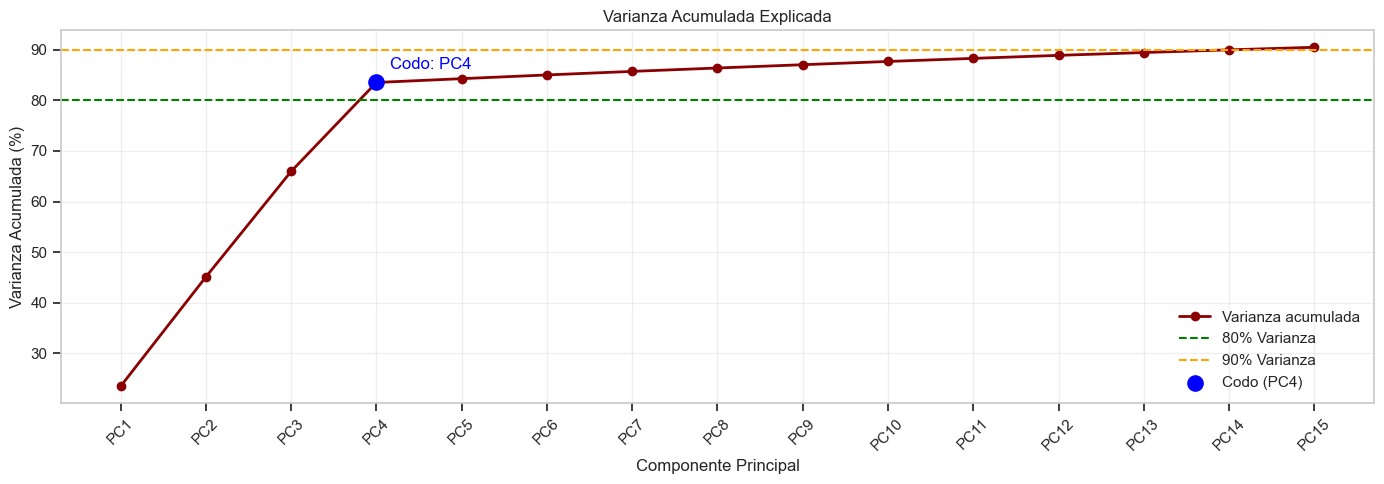


Algunos insights:
Número de componentes para explicar 80% de varianza: 4
Número de componentes para explicar 90% de varianza: 15


In [90]:
# Gráfico 2: Varianza acumulada
import numpy as np
import matplotlib.pyplot as plt

# Forzar el codo en el PC4 (índice 3)
codo_idx = 3
var_acum = df_autovalores['Varianza_Acumulada_%'][:15].values

fig, ax = plt.subplots(1, figsize=(14, 5))
ax.plot(df_autovalores['Componente'][:15], var_acum, marker='o', color='darkred', linewidth=2, label='Varianza acumulada')
ax.axhline(y=80, color='green', linestyle='--', label='80% Varianza')
ax.axhline(y=90, color='orange', linestyle='--', label='90% Varianza')

# Marcar el codo en PC4
ax.scatter(df_autovalores['Componente'].iloc[codo_idx], var_acum[codo_idx], color='blue', s=120, zorder=5, label='Codo (PC4)')
ax.annotate(f'Codo: {df_autovalores["Componente"].iloc[codo_idx]}',
            (df_autovalores['Componente'].iloc[codo_idx], var_acum[codo_idx]),
            textcoords="offset points", xytext=(10,10), ha='left', color='blue', fontsize=12)

ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza Acumulada (%)')
ax.set_title('Varianza Acumulada Explicada')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAlgunos insights:")
print(f"Número de componentes para explicar 80% de varianza: {(df_autovalores['Varianza_Acumulada_%'] <= 80).sum() + 1}")
print(f"Número de componentes para explicar 90% de varianza: {(df_autovalores['Varianza_Acumulada_%'] <= 90).sum() + 1}")


#### Paso 6: Interpretación de Cargas (Loadings)
Este es el paso final para el modelador. Debes mirar qué variables originales "pesan" más en cada componente.

Ejemplo: Si el PC1 tiene pesos altos en "Ventas", "Nuevos Clientes" y "Market Share", puedes bautizar al PC1 como "Crecimiento de Mercado".

**¿que pasó en nuestro ejemplo?** 

Para interpretar las cargas de los cuatro primeros componentes principales (PCA), debes observar los pesos (coeficientes) de cada variable original en cada componente. Estos valores indican qué tanto contribuye cada variable a cada componente:

Un valor alto (positivo o negativo) significa que la variable tiene mucha influencia en ese componente.
Si varias variables de un mismo grupo (por ejemplo, KPIs de operaciones) tienen cargas altas en un componente, ese componente resume la información de ese grupo.

In [91]:
# Resumen de las cargas (loadings) de los 4 primeros componentes principales
import pandas as pd
import numpy as np

# DataFrame de cargas: filas=variables, columnas=componentes
cargas = pd.DataFrame(
    autovectores_ordenados[:, :4],
    index=df_kpis_estandarizado.columns,
    columns=[f'PC{i+1}' for i in range(4)]
)

# Mostrar las 5 variables con mayor valor absoluto en cada componente
for i in range(4):
    pc = f'PC{i+1}'
    print(f'\nVariables más importantes en {pc}:')
    display(cargas[pc].abs().sort_values(ascending=False).head(5))





Variables más importantes en PC1:


RH_Gasto_Nomina_Ventas    0.243377
RH_Ausentismo             0.241616
RH_Indice_Clima           0.241593
RH_Tiempo_Contratacion    0.241309
RH_Antiguedad_Promedio    0.240834
Name: PC1, dtype: float64


Variables más importantes en PC2:


OP_Capacidad_Utilizada    0.184284
OP_Cumplimiento_Plan      0.183812
OP_Ciclo_Produccion       0.182073
FIN_Apalancamiento        0.180900
OP_Costo_Unitario         0.180506
Name: PC2, dtype: float64


Variables más importantes en PC3:


FIN_Margen_EBITDA           0.220646
FIN_Dias_Cuentas_Cobrar     0.213710
FIN_Variacion_Gastos_Adm    0.213141
FIN_Costo_Deuda             0.212876
FIN_Ratio_Liquidez          0.212770
Name: PC3, dtype: float64


Variables más importantes en PC4:


MKT_Tasa_Recomendacion    0.289080
MKT_Frecuencia_Compra     0.289069
MKT_NPS                   0.288739
MKT_Costo_Por_Click       0.288609
MKT_Market_Share          0.288258
Name: PC4, dtype: float64

In [92]:
# Interpretación de los 4 primeros componentes principales
for i in range(4):
    pc = f'PC{i+1}'
    top_vars = cargas[pc].abs().sort_values(ascending=False).head(5).index.tolist()
    print(f"\n{pc}: Las variables con mayor peso son: {', '.join(top_vars)}.")
    print(f"Esto sugiere que {pc} resume principalmente la variabilidad de estas variables.")



PC1: Las variables con mayor peso son: RH_Gasto_Nomina_Ventas, RH_Ausentismo, RH_Indice_Clima, RH_Tiempo_Contratacion, RH_Antiguedad_Promedio.
Esto sugiere que PC1 resume principalmente la variabilidad de estas variables.

PC2: Las variables con mayor peso son: OP_Capacidad_Utilizada, OP_Cumplimiento_Plan, OP_Ciclo_Produccion, FIN_Apalancamiento, OP_Costo_Unitario.
Esto sugiere que PC2 resume principalmente la variabilidad de estas variables.

PC3: Las variables con mayor peso son: FIN_Margen_EBITDA, FIN_Dias_Cuentas_Cobrar, FIN_Variacion_Gastos_Adm, FIN_Costo_Deuda, FIN_Ratio_Liquidez.
Esto sugiere que PC3 resume principalmente la variabilidad de estas variables.

PC4: Las variables con mayor peso son: MKT_Tasa_Recomendacion, MKT_Frecuencia_Compra, MKT_NPS, MKT_Costo_Por_Click, MKT_Market_Share.
Esto sugiere que PC4 resume principalmente la variabilidad de estas variables.


In [93]:
# Si quieres ver todas las cargas:
display(cargas)

,PC1,PC2,PC3,PC4
OP_Ciclo_Produccion,0.136941,-0.182073,0.175845,0.023511
OP_Tasa_Defectos,0.132431,-0.177091,0.183221,0.017768
OP_Disponibilidad_Maq,0.137347,-0.174586,0.184728,0.022067
OP_Costo_Unitario,0.139253,-0.180506,0.177007,0.021790
OP_Merma_Materia_Prima,0.138650,-0.179879,0.175299,0.024795
OP_Cumplimiento_Plan,0.131625,-0.183812,0.176286,0.017079
OP_Eficiencia_Energetica,0.136203,-0.173125,0.184968,0.019472
OP_Rotacion_Inventario,0.137986,-0.174256,0.181433,0.031583
OP_Tiempo_Set_Up,0.134592,-0.174514,0.185480,0.022860
OP_Productividad_HH,0.134570,-0.177835,0.183142,0.019636


---

## 🧪 Taller Práctico: Distancias y PCA con Mall Customers

**Objetivo:** Aplicar los conceptos de distancia y PCA vistos en clase usando la base de datos de clientes de un centro comercial.

**Base de datos:** `Mall_Customers.csv`  
Contiene información de 200 clientes con las variables:
- `CustomerID`: identificador del cliente
- `Genre`: género (Male/Female)
- `Age`: edad
- `Annual Income (k$)`: ingreso anual en miles de dólares
- `Spending Score (1-100)`: índice de gasto asignado por el mall

---

### Ejercicio 1 — Carga y Exploración de Datos

Carga la base de datos y realiza un análisis exploratorio básico:
- Muestra las primeras filas.
- Verifica tipos de datos y valores nulos.
- Describe estadísticamente las variables numéricas.


In [94]:
# Ejercicio 1: Carga y exploración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Carga la base de datos
df_mall = pd.read_csv("Mall_Customers.csv")

# Tu código aquí:
# 1. Muestra las primeras 5 filas
# display(df_mall.head())

# 2. Verifica tipos y nulos
# df_mall.info()

# 3. Descripción estadística
# display(df_mall.describe())


### Ejercicio 2 — Cálculo de Distancias

Usando las variables numéricas `Age`, `Annual Income (k$)` y `Spending Score (1-100)`:

1. Selecciona los clientes 0 y 1 como vectores **a** y **b**.
2. Calcula la distancia **Euclidiana** y **Manhattan** entre ellos.
3. Calcula la distancia **Mahalanobis** usando la matriz de covarianza del dataset completo.
4. ¿Por qué la distancia Mahalanobis puede dar un resultado diferente a la Euclidiana? Explica con tus palabras.


In [95]:
# Ejercicio 2: Cálculo de distancias
from scipy.spatial.distance import euclidean, cityblock, mahalanobis

# Variables numéricas de interés
vars_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_mall = df_mall[vars_num].values

# Vectores de los primeros dos clientes
a_mall = X_mall[0]
b_mall = X_mall[1]

# Tu código aquí:
# 1. Distancia Euclidiana
# dist_euc = euclidean(a_mall, b_mall)
# print(f"Euclidiana: {dist_euc:.2f}")

# 2. Distancia Manhattan
# dist_man = cityblock(a_mall, b_mall)
# print(f"Manhattan: {dist_man:.2f}")

# 3. Distancia Mahalanobis
# S_mall = np.cov(X_mall, rowvar=False)
# S_inv_mall = np.linalg.inv(S_mall)
# dist_mah = mahalanobis(a_mall, b_mall, S_inv_mall)
# print(f"Mahalanobis: {dist_mah:.2f}")


### Ejercicio 3 — Matriz de Distancias

1. Construye una **matriz de distancias Euclidianas** para los primeros 20 clientes.
2. Visualízala como un mapa de calor.
3. ¿Qué par de clientes es el más similar? ¿Y el más diferente?

> **Pista:** Usa `pdist` y `squareform` de `scipy.spatial.distance`.


In [96]:
# Ejercicio 3: Matriz de distancias
from scipy.spatial.distance import pdist, squareform

# Tu código aquí:
# 1. Selecciona los primeros 20 clientes
# subset_mall = X_mall[:20]

# 2. Construye la matriz de distancias
# mat_dist_mall = squareform(pdist(subset_mall, metric='euclidean'))

# 3. Visualiza con heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(mat_dist_mall, cmap='YlOrRd',
#             xticklabels=range(1, 21), yticklabels=range(1, 21))
# plt.title("Matriz de distancias Euclidianas (20 clientes)")
# plt.show()

# 4. Par más similar y más diferente
# np.fill_diagonal(mat_dist_mall, np.nan)
# idx_min = np.unravel_index(np.nanargmin(mat_dist_mall), mat_dist_mall.shape)
# idx_max = np.unravel_index(np.nanargmax(mat_dist_mall), mat_dist_mall.shape)
# print(f"Par más similar: clientes {idx_min[0]+1} y {idx_min[1]+1}")
# print(f"Par más diferente: clientes {idx_max[0]+1} y {idx_max[1]+1}")


### Ejercicio 4 — Estandarización y PCA

1. Selecciona las variables numéricas `Age`, `Annual Income (k$)` y `Spending Score (1-100)`.
2. Estandariza los datos con `StandardScaler`.
3. Aplica PCA con todos los componentes posibles.
4. Genera el **Scree Plot** (varianza explicada por componente).
5. ¿Cuántos componentes conservarías? Justifica usando el criterio de Kaiser o el gráfico de codo.


In [97]:
# Ejercicio 4: Estandarización y PCA
from sklearn.decomposition import PCA

# Tu código aquí:
# 1. Estandarizar
# scaler_mall = StandardScaler()
# X_mall_std = scaler_mall.fit_transform(df_mall[vars_num])

# 2. Aplicar PCA
# pca_mall = PCA()
# pca_mall.fit(X_mall_std)

# 3. Varianza explicada
# varianza_exp = pca_mall.explained_variance_ratio_ * 100
# varianza_acum = np.cumsum(varianza_exp)

# 4. Scree Plot
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# ax1.bar([f'PC{i+1}' for i in range(len(varianza_exp))], varianza_exp, color='steelblue')
# ax1.set_title('Varianza Explicada por Componente')
# ax1.set_ylabel('%')
# ax2.plot([f'PC{i+1}' for i in range(len(varianza_acum))], varianza_acum, marker='o', color='darkred')
# ax2.axhline(y=80, color='green', linestyle='--', label='80%')
# ax2.axhline(y=90, color='orange', linestyle='--', label='90%')
# ax2.set_title('Varianza Acumulada')
# ax2.legend()
# plt.tight_layout()
# plt.show()

# 5. Criterio de Kaiser (autovalores > 1)
# autoval_mall = pca_mall.explained_variance_
# n_kaiser = (autoval_mall > 1).sum()
# print(f"Componentes con autovalor > 1 (criterio de Kaiser): {n_kaiser}")


### Ejercicio 5 — Interpretación de Cargas (Loadings)

1. Obtén la matriz de **cargas** (loadings) del PCA.
2. ¿Qué variable tiene mayor peso en el primer componente (PC1)?
3. ¿Qué variable tiene mayor peso en el segundo componente (PC2)?
4. Intenta ponerle un nombre descriptivo a cada componente según las variables que más pesan en él.

> **Ejemplo:** Si `Annual Income` y `Spending Score` tienen pesos altos en PC1, podrías llamarlo *"Perfil de Consumo"*.


In [98]:
# Ejercicio 5: Cargas del PCA
# Tu código aquí:

# 1. DataFrame de cargas
# cargas_mall = pd.DataFrame(
#     pca_mall.components_.T,
#     index=vars_num,
#     columns=[f'PC{i+1}' for i in range(len(vars_num))]
# )
# display(cargas_mall.round(3))

# 2. Variable con mayor peso en PC1 y PC2
# print("\nVariable con mayor peso en PC1:", cargas_mall['PC1'].abs().idxmax())
# print("Variable con mayor peso en PC2:", cargas_mall['PC2'].abs().idxmax())

# 3. Heatmap de cargas
# plt.figure(figsize=(7, 4))
# sns.heatmap(cargas_mall, annot=True, cmap='coolwarm', center=0, fmt='.2f')
# plt.title('Cargas (Loadings) del PCA - Mall Customers')
# plt.show()

# 4. Escribe aquí tus nombres para cada componente:
# PC1 = "..."
# PC2 = "..."


### Ejercicio 6 (Reto) — Visualización en 2D con PCA

1. Transforma los datos originales al espacio de los dos primeros componentes principales.
2. Genera un **gráfico de dispersión** (scatter plot) usando PC1 en el eje X y PC2 en el eje Y.
3. Colorea los puntos según el género (`Genre`) del cliente.
4. ¿Se observan grupos o patrones visuales? Descríbelos brevemente.

> **Reflexión:** ¿Qué ventaja tiene visualizar los datos en el espacio PCA en lugar del espacio original?


In [99]:
# Ejercicio 6 (Reto): Visualización 2D con PCA
# Tu código aquí:

# 1. Transformar datos al espacio PCA (2 componentes)
# X_pca2 = pca_mall.transform(X_mall_std)[:, :2]
# df_pca2 = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])
# df_pca2['Genre'] = df_mall['Genre'].values

# 2. Scatter plot coloreado por género
# colores = {'Male': 'steelblue', 'Female': 'tomato'}
# fig, ax = plt.subplots(figsize=(8, 6))
# for genero, grupo in df_pca2.groupby('Genre'):
#     ax.scatter(grupo['PC1'], grupo['PC2'],
#                label=genero, color=colores[genero], alpha=0.7, edgecolors='k', s=60)
# ax.set_xlabel(f'PC1 ({varianza_exp[0]:.1f}% varianza)')
# ax.set_ylabel(f'PC2 ({varianza_exp[1]:.1f}% varianza)')
# ax.set_title('Clientes Mall en espacio PCA (2 componentes)')
# ax.legend(title='Género')
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# 3. Escribe aquí tu reflexión:
# "Los patrones observados son..."
